<a href="https://colab.research.google.com/github/samiraQS/AI-ML-ENG-/blob/main/AI_ML_ENG_Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 3: Heart Disease Prediction

## Libraries

In [1]:
import pandas as pd # Imported required libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split # function to split the dataset into training and testing sets
from sklearn.linear_model import LogisticRegression #Import the Logistic Regression classification model
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc #Import evaluation metrics to measure model performance

## Load dataset

In [3]:
# Load the dataset
heart = pd.read_csv('heart_disease_uci.csv')

# Display first 5 rows
print(heart.head())

FileNotFoundError: [Errno 2] No such file or directory: 'heart_disease_uci.csv'

## Dataset Inspection

In [ ]:
# Shape of dataset
print("Shape:", heart.shape)

# Column names
print("Columns:")
print(heart.columns)

# Dataset information
heart.info()

# Summary statistics
print(heart.describe())

Shape: (920, 16)
Columns:
Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int

# 1. Data Cleaning

In [ ]:
print(heart.isnull().sum()) # Check missing values

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


# 2. Exploratory Data Analysis (EDA)

## Num Variable Distribution

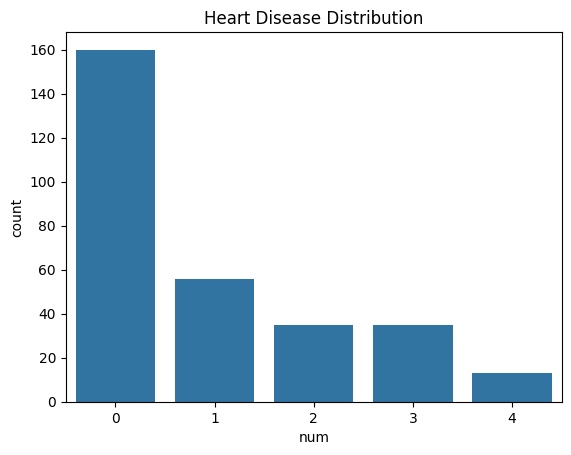

In [ ]:
sns.countplot(x='num', data=heart) # Create a count plot to show the distribution of patients with and without heart disease
plt.title("Heart Disease Distribution")
plt.show()

## Correlation heatmap

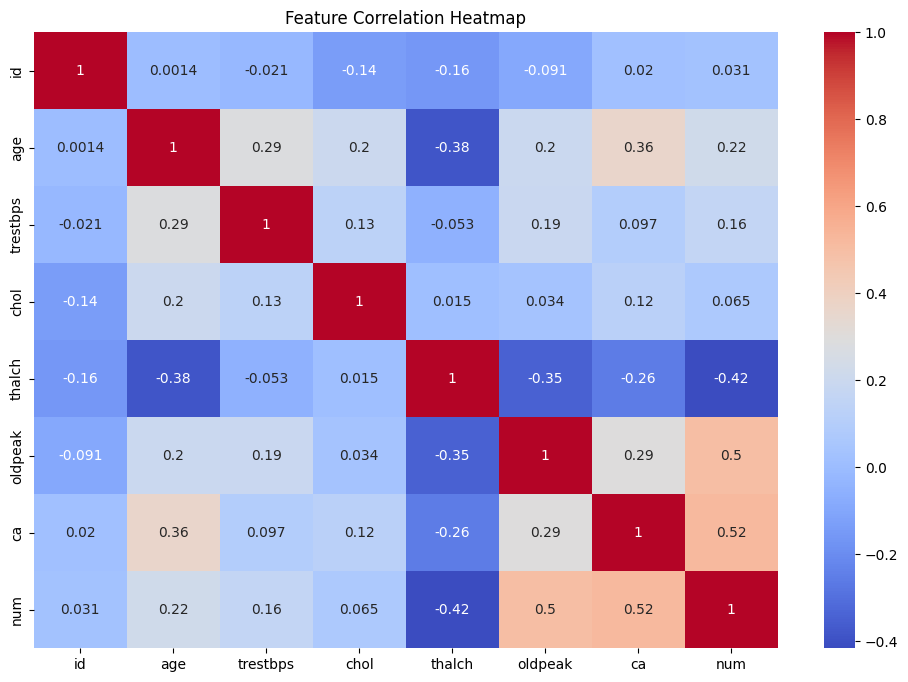

In [ ]:
numeric_heart = heart.select_dtypes(include=['number']) # Select only the numerical columns from the dataset. This excludes categorical columns that cannot be used for correlation analysis

plt.figure(figsize=(12,8))

sns.heatmap( # Create a heatmap to visualize the correlation between numerical features
    numeric_heart.corr(),
    annot=True,  #annot=True displays the correlation values inside each cell
    cmap='coolwarm' # cmap='coolwarm' uses a color gradient to represent correlation strength
)

plt.title("Feature Correlation Heatmap")
plt.show()

## Age Distribution

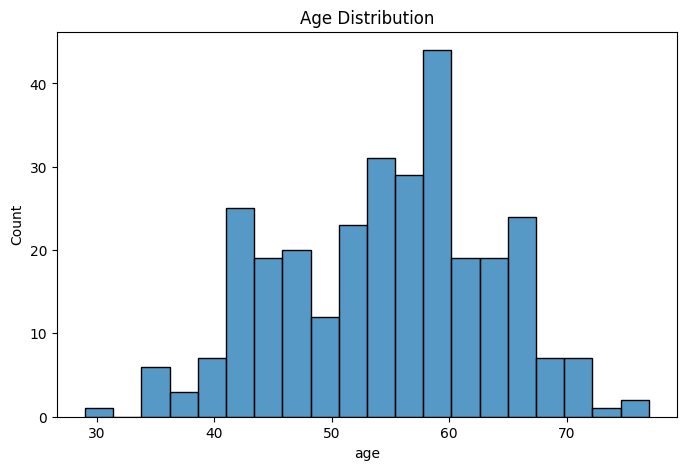

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(heart['age'], bins=20) # Create a histogram to display the distribution of patients' ages
# bins=20 divides the age values into 20 intervals

plt.title("Age Distribution")
plt.show()

## Convert categorical variables

In [ ]:
# Convert categorical columns into numerical columns
heart_encoded = pd.get_dummies(heart, drop_first=True)

print(heart_encoded.head())

   id  age  trestbps   chol  thalch  oldpeak   ca  num  sex_Male  \
0   1   63     145.0  233.0   150.0      2.3  0.0    0      True   
1   2   67     160.0  286.0   108.0      1.5  3.0    2      True   
2   3   67     120.0  229.0   129.0      2.6  2.0    1      True   
3   4   37     130.0  250.0   187.0      3.5  0.0    0      True   
4   5   41     130.0  204.0   172.0      1.4  0.0    0     False   

   dataset_Hungary  ...  cp_non-anginal  cp_typical angina  fbs_True  \
0            False  ...           False               True      True   
1            False  ...           False              False     False   
2            False  ...           False              False     False   
3            False  ...            True              False     False   
4            False  ...           False              False     False   

   restecg_normal  restecg_st-t abnormality  exang_True  slope_flat  \
0           False                     False       False       False   
1           Fals

## Define features and target

In [ ]:
X = heart_encoded.drop('num', axis=1) # Define the feature variables (independent variables)
# Drop the target column 'num' so that only input features remain

y = heart_encoded['num'] # Define the target variable (dependent variable)
# The 'num' column contains the heart disease labels

## Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( # Split the dataset into training and testing sets
    X,
    y,
    test_size=0.2, # 80% of the data is used for training and 20% for testing
    random_state=42 # random_state=42 ensures the same data split is produced every time the code is run
)

# 3. Train Logistic Regession Model

In [ ]:
model = LogisticRegression( # Create a Logistic Regression model
    max_iter=5000 # max_iter=5000 increases the maximum number of iterations to help the model converge during training
)

model.fit(
    X_train, # X_train contains the input features and y_train contains the target labels
    y_train
)

LogisticRegression(max_iter=5000)

# 4. Evaluate using metrics: accuracy, ROC curve, and confusion matrix.

## Make Predictions

In [ ]:
y_pred = model.predict(X_test) # Use the trained Logistic Regression model to predict the heart disease status for the testing dataset

## Accuracy

In [ ]:
accuracy = accuracy_score(  # Calculate the accuracy of the Logistic Regression model by comparing the actual values with the predicted values
    y_test,
    y_pred
)

print("\nAccuracy:", accuracy)


Accuracy: 0.9166666666666666


## ROC curve

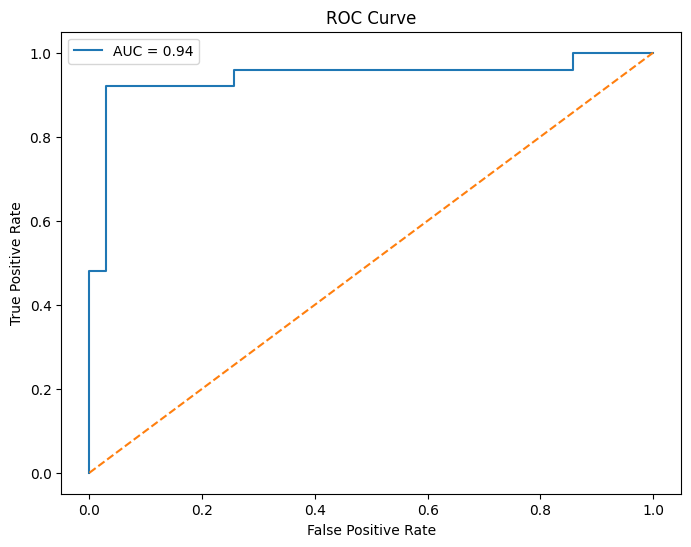

AUC Score: 0.9428571428571428


In [ ]:
y_prob = model.predict_proba(X_test)[:, 1] # Predict the probability of each class for the testing data [:, 1] selects the probability of the positive class (Heart Disease = 1)

fpr, tpr, thresholds = roc_curve( # Calculate the False Positive Rate (FPR), True Positive Rate (TPR), and threshold values for plotting the ROC curve
    y_test,
    y_prob
)

roc_auc = auc( # Calculate the Area Under the ROC Curve (AUC). A higher AUC value indicates better model performance
    fpr,
    tpr
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot( # Plot a diagonal reference line representing a random classifier
    [0, 1],
    [0, 1],
    '--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()

plt.show()

print("AUC Score:", roc_auc)

## Confussion Matrix

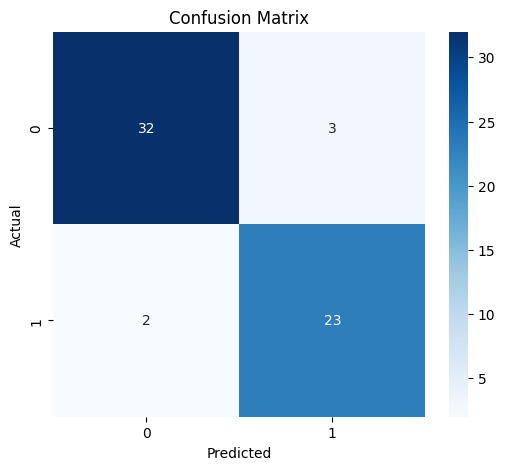

In [ ]:
cm = confusion_matrix( # Calculate the confusion matrix by comparing the actual labels with the predicted labels
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap( # Display the confusion matrix as a heatmap
    cm,
    annot=True, # annot=True displays the values inside each cell
    fmt='d', # fmt='d' displays the values as integers
    cmap='Blues' # cmap='Blues' applies a blue color scheme
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Feature Importance

In [ ]:
feature_importance = pd.DataFrame({ # Create a DataFrame containing each feature and its corresponding
    'Feature': X.columns,
    'Coefficient': model.coef_[0] # coefficient from the trained Logistic Regression model
})

feature_importance = feature_importance.sort_values( # Sort the features based on their coefficients in descending order
# Features with larger positive coefficients appear first
    by='Coefficient',
    ascending=False
)

print("\nMost Important Features:")
print(feature_importance.head(10))


Most Important Features:
                   Feature  Coefficient
7                 sex_Male     1.203332
6                       ca     1.074033
16              exang_True     0.915023
20  thal_reversable defect     0.627725
17              slope_flat     0.507898
5                  oldpeak     0.394178
9    dataset_VA Long Beach     0.052877
8          dataset_Hungary     0.022085
2                 trestbps     0.018786
3                     chol     0.003968


## Feature Importance Plot

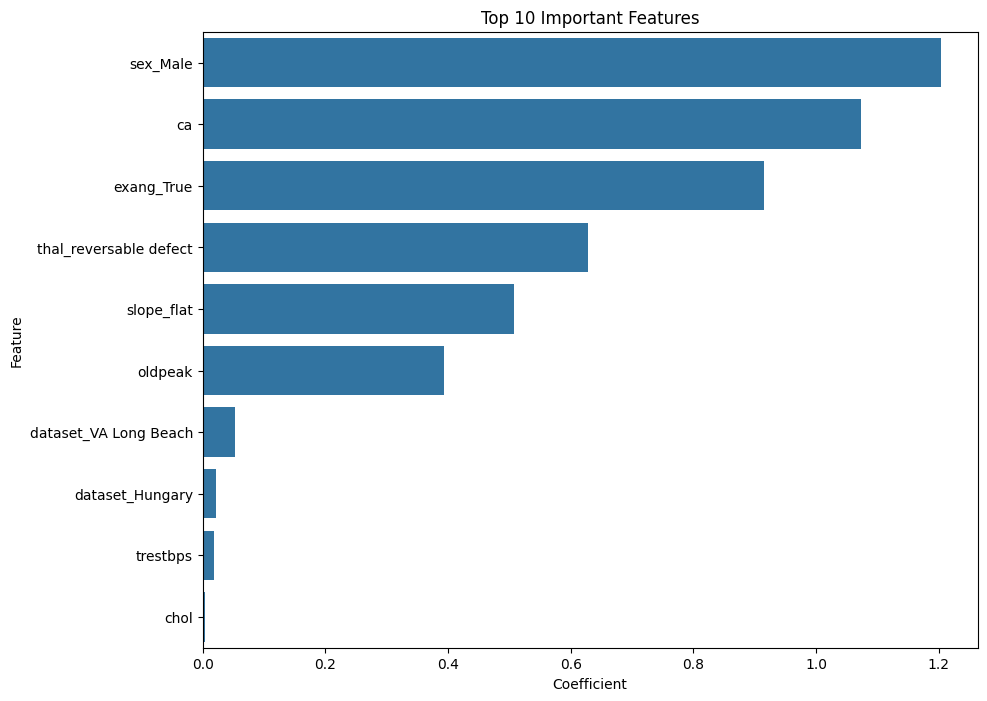

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot( # Create a horizontal bar chart to visualize the top 10 most important features
    data=feature_importance.head(10),
    x='Coefficient', # The x-axis represents the coefficient values and the y-axis shows the feature names
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()